#  Audio signal filtering

### Importing libraries

In [1]:
from numpy import sin, cos, pi, exp, mean, absolute, angle, conj # Sentral math functions
from numpy.fft import fft, ifft             # DFT and IDFT
import numpy as np                          # Import function from numpy library with prefix "np"
import matplotlib.pyplot as plt             # Import pyplot modual from matplotlib with prefix "plt"
from scipy.io import wavfile                # Audio file I/O
from IPython.display import Audio           # Audio widget for embedded audio play
import scipy.signal as sig
%matplotlib notebook

### Audiofile upload

16000


<IPython.core.display.Javascript object>


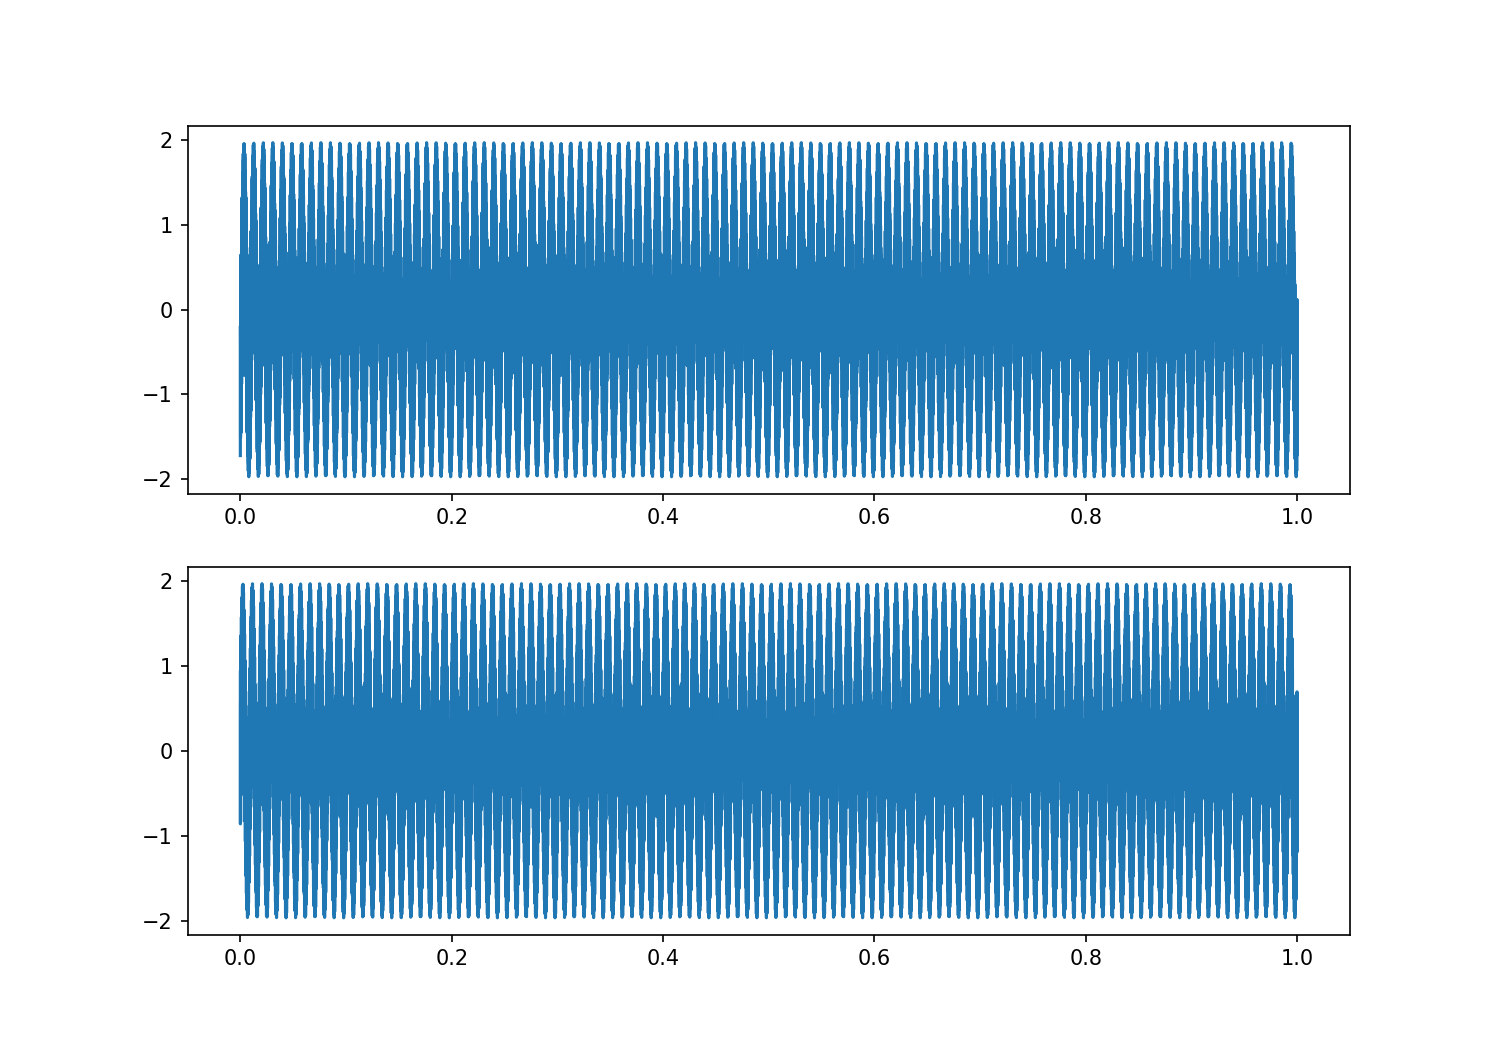

In [2]:
# Load sample values and sampling rate.
fs, data = wavfile.read(r'forelesningsopptak.wav') 
# Separate two microphone signals and convert datatype from int16 to float values from -1.0 to 1.0.
xn1 = data.T[0]/0x8000
xn2 = data.T[1]/0x8000

# Check sampling rate of files.
print(fs)

# Test sinus waves with different frequencies to see what our code does.
T = 1
t_n = np.linspace(0, T, T*fs, endpoint=False)

xn1_t = cos(2*pi*10000*(t_n-3.0/343))+ cos(2*pi*110*(t_n-1.2/343))
xn2_t = cos(2*pi*10000*(t_n-3.5/343))+ cos(2*pi*110*(t_n-0.8/343))


# Graph of our test signals plotted over each other.
plt.close(1)
plt.figure(1, figsize=(10,7))
plt.subplot(2,1,1)
plt.plot(t_n, xn1_t)
plt.subplot(2,1,2)
plt.plot(t_n, xn2_t)


# Audio from microphone 1 'xn1'.
Audio(xn1, rate=fs)

In [3]:
# Audio from microphone 2 'xn2'.
Audio(xn2, rate=fs)

# Beamforming

## Integer delay

<IPython.core.display.Javascript object>


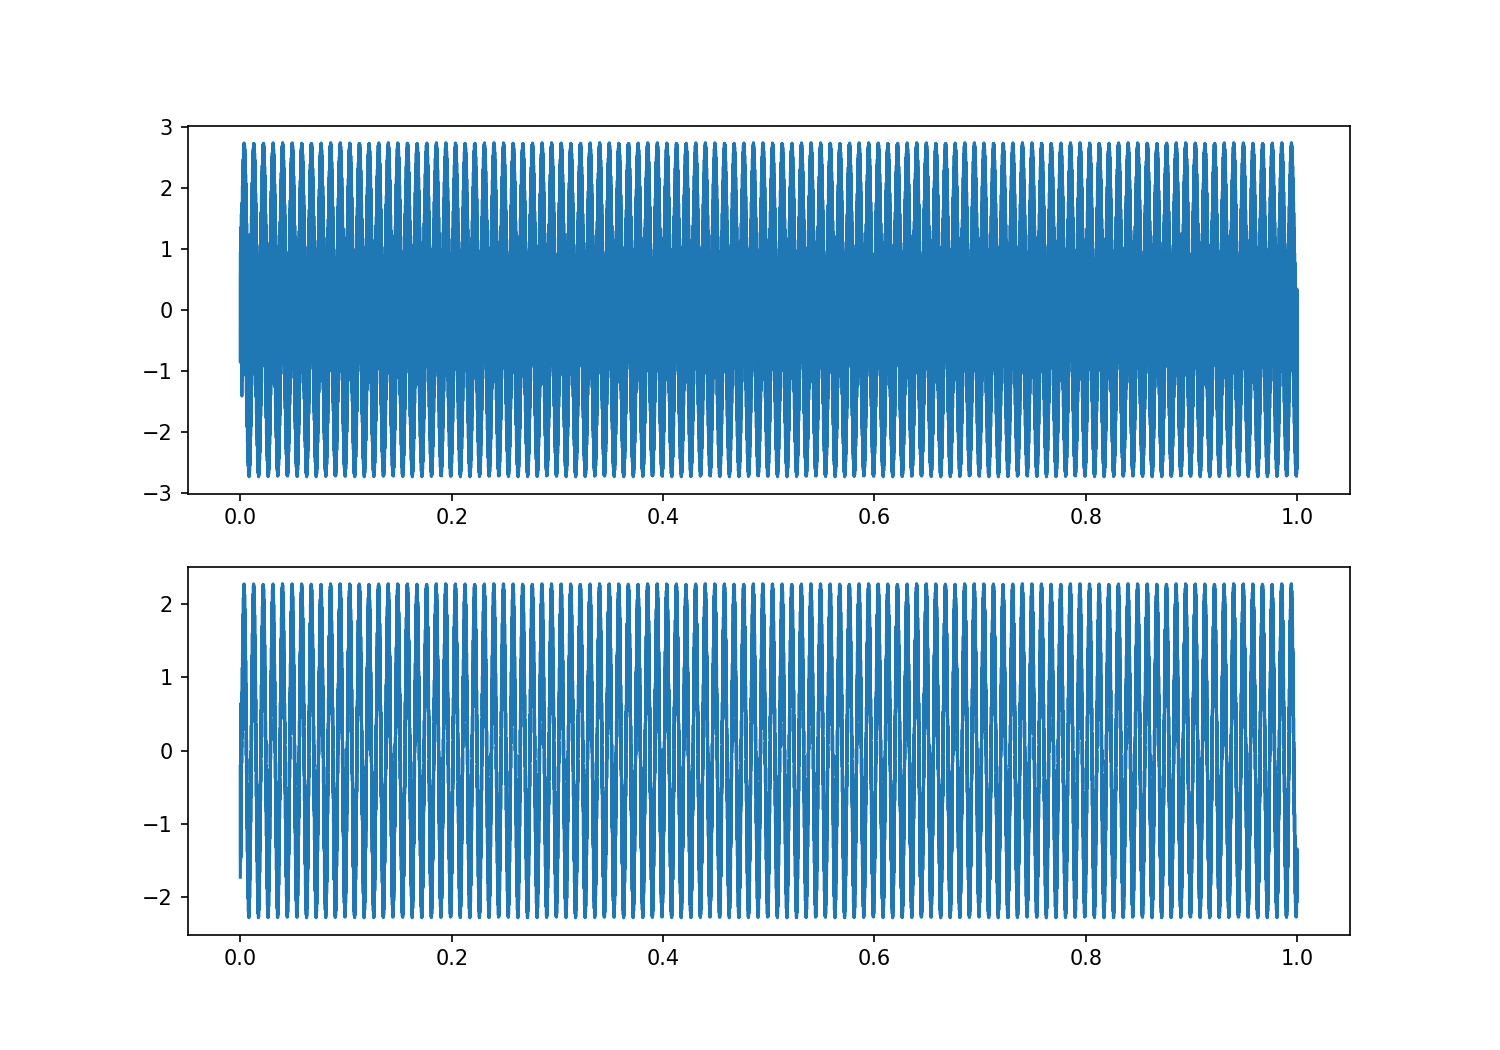

In [4]:
# Make a signal that is 23 samples behind input.
hn_1 = np.zeros(24)            # Create an array with 24 zeros from 0 to 23.
hn_1[23] = 1                   # Change last value (nr. 23) of array to 1.
yn_1 = np.convolve(xn1, hn_1)  # With numpy convolve function we convolve input signal from microphone 1 
                               # with time delay and get signal that is 23 samples delayed.

# Add delayed signal of microphone 1 to signal of microphone 2. This way we get baby's voice in sync and amplified.
indices_1 = list(range(0, len(xn2)))
yn_1 = yn_1[indices_1]
vn_1 = yn_1 + xn2              # Add signal arrays together to get amplified baby's voice.


# Make a signal that is 19 samples behind input.
hn_2 = np.zeros(20)            # Create an array with 20 zeros from 0 to 19.
hn_2[19] = 1                   # Change last value (nr. 19) of array to 1.
yn_2 = np.convolve(xn2, hn_2)  # With numpy convolve function we convolve input signal from microphone 1 
                               # With time delay and get signal that is 19 samples delayed.

# Add delayed signal of microphone 2 to signal of microphone 1. This way we get adult's voice in sync and amplified.
indices_2 = list(range(0, len(xn1)))
yn_2 = yn_2[indices_2]
vn_2 = yn_2 + xn1              # Add signal arrays together to get amplified adult's voice.


# Test signal.
yn1_t = np.convolve(xn1_t, hn_1)
indices1_t = list(range(0, T*fs))
yn1_t = yn1_t[indices1_t]
vn1_t = yn1_t + xn2_t

yn2_t = np.convolve(xn2_t, hn_2)
yn2_t = yn2_t[indices1_t]
vn2_t = yn2_t + xn1_t

# Graphs to see what happens with our signal when we delay it
plt.close(2)
plt.figure(2, figsize=(10,7))
plt.subplot(2,1,1)
plt.plot(t_n, vn1_t)
plt.subplot(2,1,2)
plt.plot(t_n, vn2_t)


# Test: Lisen to what is happening with the audio signal.
Audio(vn_1, rate=fs)           # Amplified baby.

In [5]:
# Test: Lisen to what is happening with the audio signal.
Audio(vn_2, rate=fs)           # Amplified adult.

## Float delay

<IPython.core.display.Javascript object>


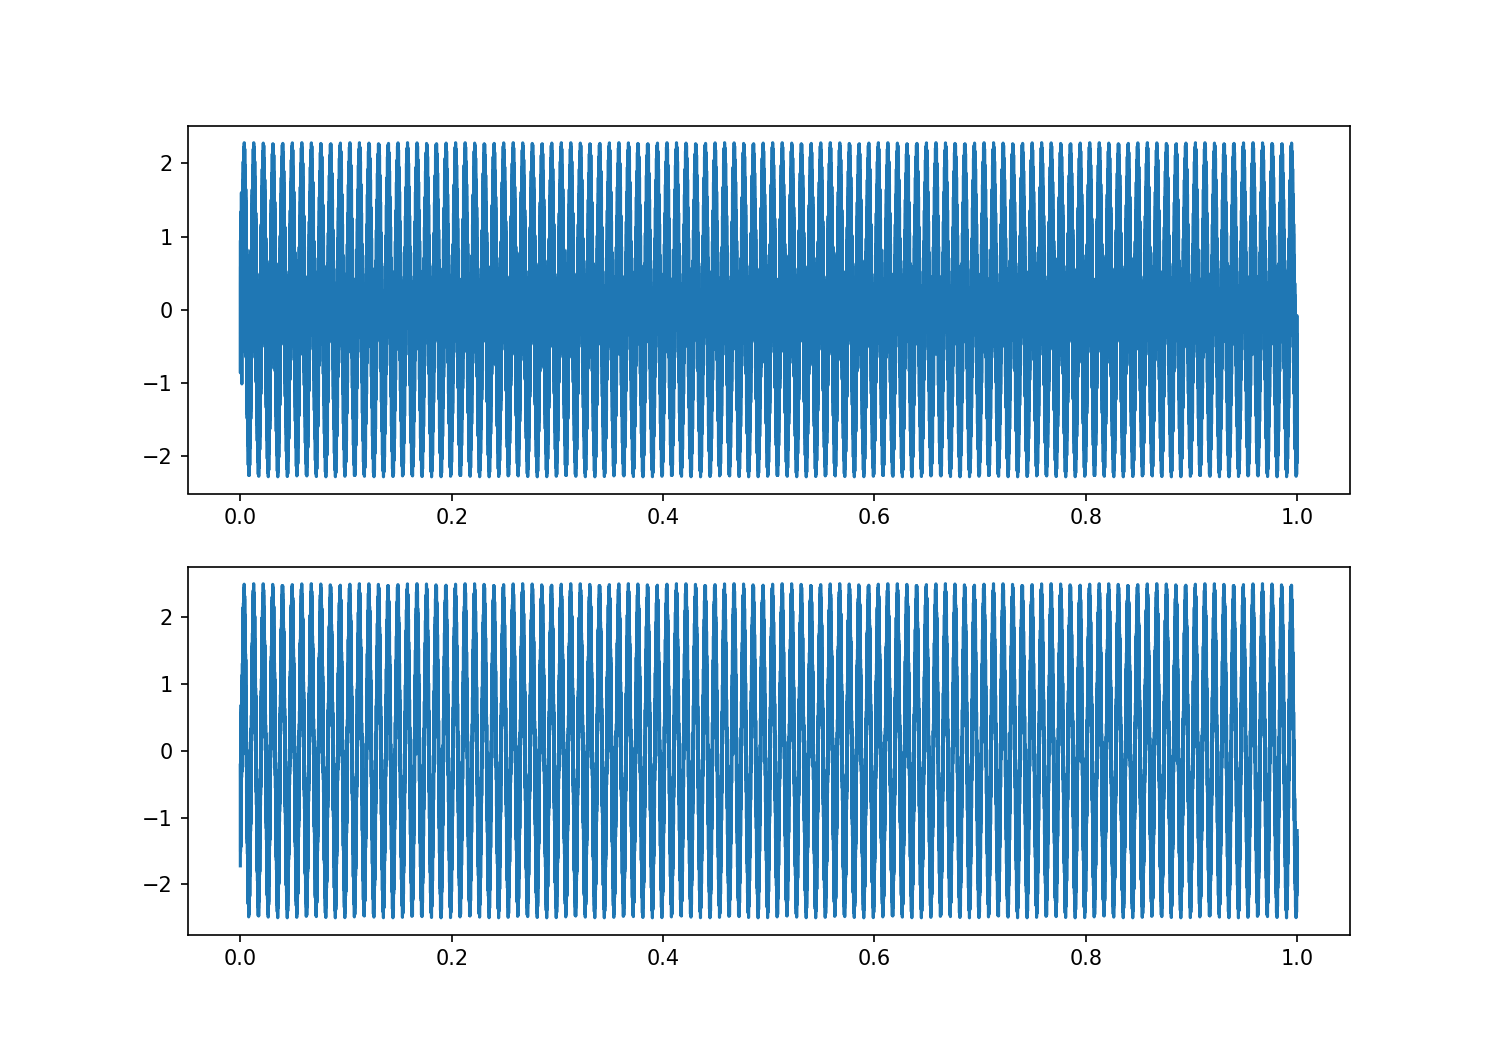

In [6]:
L1 = 8000/343                                     # Amount of samples baby's voice is out of synch.
M1 = int(L1*2)                                    # Filters order
Lenght1 = M1+1                                    # The transfer function of the length.

num1 = np.arange(Lenght1) 
hn1_f = np.sinc((num1-L1))*sig.hamming(Lenght1)   # Formula of the impulse response.

yn1_f = sig.lfilter(hn1_f, 1, xn1)                # Applying filter to the impulse response.

L2 = 6400/343                                     # Amount of samples adults's voice is out of synch.
M2 = int(L2*2)                                    # Filters order.
Lenght2 = M2+1                                    # The transfer function of the length

num2 = np.arange(Lenght2)                         # Arrange the array of the length
hn2_f = np.sinc((num2-L2))*sig.hamming(Lenght2)   # Formula of the impulse response
yn2_f = sig.lfilter(hn2_f, 1, xn2)                # Implementing the filter to the impulse respoinse

vn1_f = (yn1_f + xn2)                             # Add signal arrays together to get amplified baby's voice.
vn2_f = (yn2_f + xn1)                             # Add signal arrays together to get amplified adult's voice.


# Test signal
yn1f_t = sig.lfilter(hn1_f, 1, xn1_t) 
yn2f_t = sig.lfilter(hn2_f, 1, xn2_t) 

vn1f_t = (yn1f_t + xn2_t)
vn2f_t = (yn2f_t + xn1_t)

# Graphs to see what happens with our signal when we delay it
plt.close(3)
plt.figure(3, figsize=(10,7))
plt.subplot(2,1,1)
plt.plot(t_n, vn1f_t)
plt.subplot(2,1,2)
plt.plot(t_n, vn2f_t)

# Filtering in frequency domain

## Integer delay

<IPython.core.display.Javascript object>


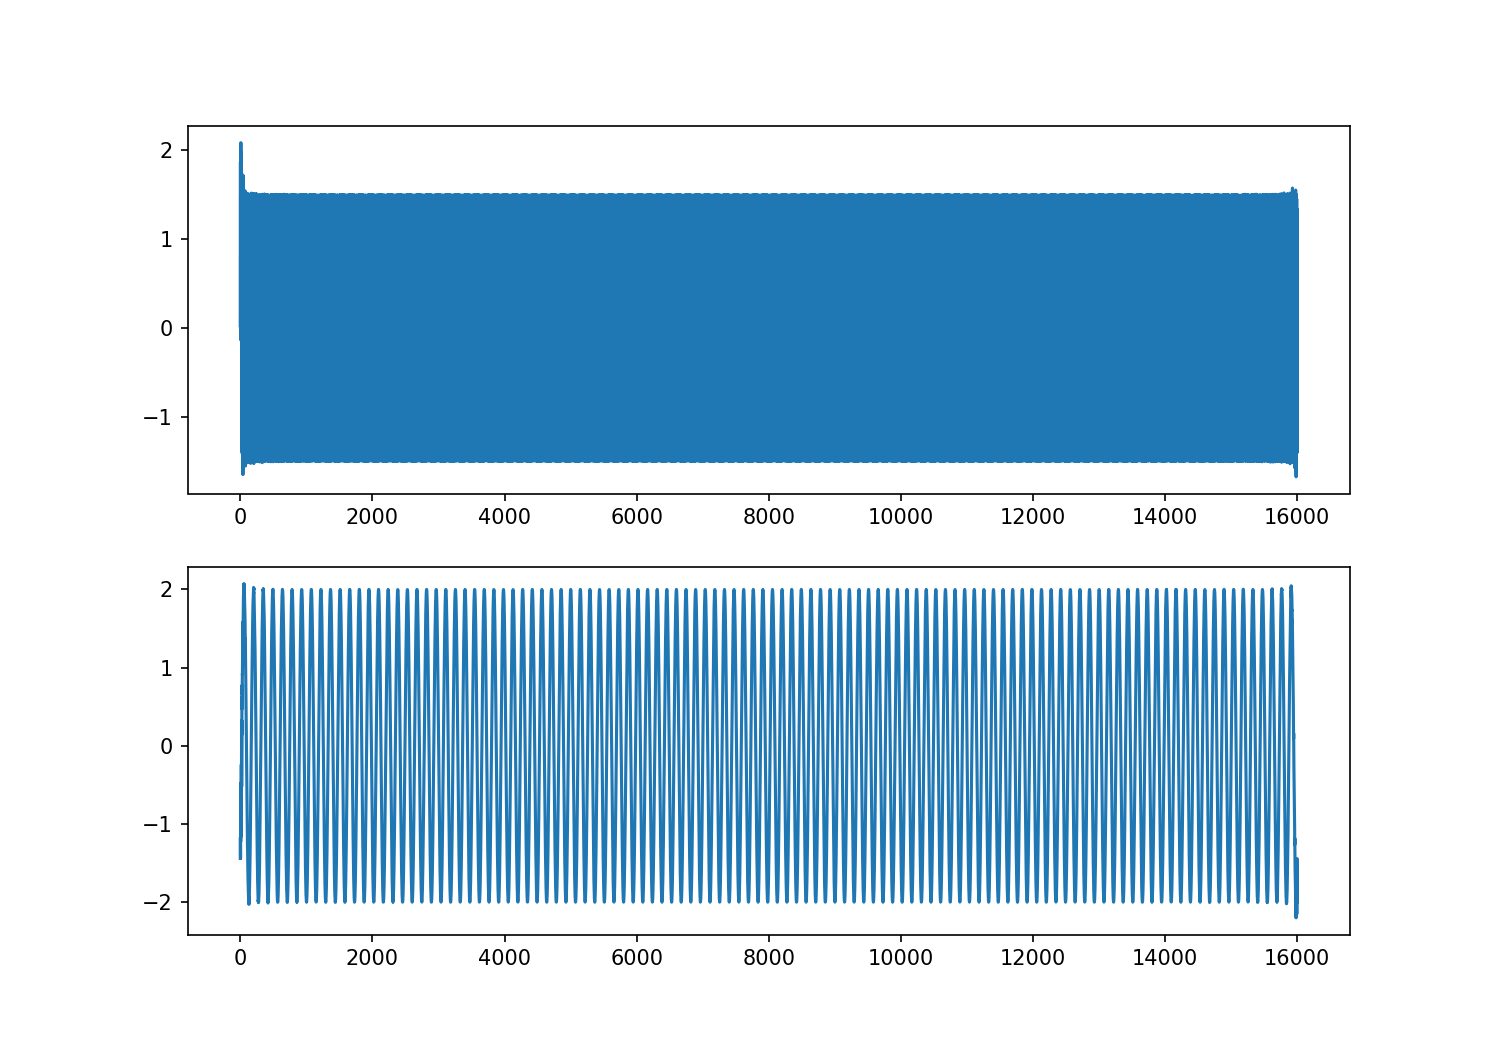

In [7]:
Vm_1 = fft(vn_1)                          # Make a DFT array of amplified baby's voice.
Vm_2 = fft(vn_2)                          # Make a DFT array of amplified adult's voice. 

Sm_1 = []                                 # Create new array Sm_1 that will hold DFT of filtered baby's voice
Sm_2 = []                                 # Create new array Sm_2 that will hold DFT of filtered adult's voice


# Mask calculation
# Here function chooses if it will keep frequency components in new array Sm_1 or if it will write zero instead. 
# Keeping baby's amplified frequencies that are stronger than of adult's amplified frequencies and putting zeros
# where adult's frequencies are stronger. In the end we should get filtered baby's voice.
for x in range(len(Vm_1)):
    if np.abs(Vm_1[x]) > np.abs(Vm_2[x]): # Checking witch voice is stronger at each frequency
        Sm_1.insert(x, Vm_1[x])         
    else:
        Sm_1.insert(x, 0)                 # Putting zero when adult's frequence is stronger that baby's.

# Here everything is done the same way as before but this time to get filtered adult's voice.
for x in range(len(Vm_2)):        
    if np.abs(Vm_2[x]) > np.abs(Vm_1[x]):
        Sm_2.insert(x, Vm_2[x])
    else:
        Sm_2.insert(x, 0)
        
        
# Invers DTF of filtered voices. Also, discard unnecessary imaginary part of signal.
sn_1 = np.real(ifft(Sm_1))           
sn_2 = np.real(ifft(Sm_2))  


# Test signal
Vm1_t = fft(vn1_t)
Vm2_t = fft(vn2_t)

Sm1_t = []
Sm2_t = []

for x in range(len(Vm1_t)):
    if np.abs(Vm1_t[x]) > np.abs(Vm2_t[x]):
        Sm1_t.insert(x, Vm1_t[x])         
    else:
        Sm1_t.insert(x, 0)  
for x in range(len(Vm2_t)):        
    if np.abs(Vm2_t[x]) > np.abs(Vm1_t[x]):
        Sm2_t.insert(x, Vm2_t[x])
    else:
        Sm2_t.insert(x, 0)

sn1_t = np.real(ifft(Sm1_t))
sn2_t = np.real(ifft(Sm2_t))

# Graphs to see what happens with our signal when we use our mask calculator
plt.close(4), plt.figure(4, figsize=(10,7))
plt.subplot(2,1,1)
plt.plot(np.arange(len(sn1_t)), sn1_t)
plt.subplot(2,1,2)
plt.plot(np.arange(len(sn2_t)), sn2_t)

# Test: Lisen to filtered baby's voice.
Audio(sn_1, rate=fs)

## Float delay

<IPython.core.display.Javascript object>


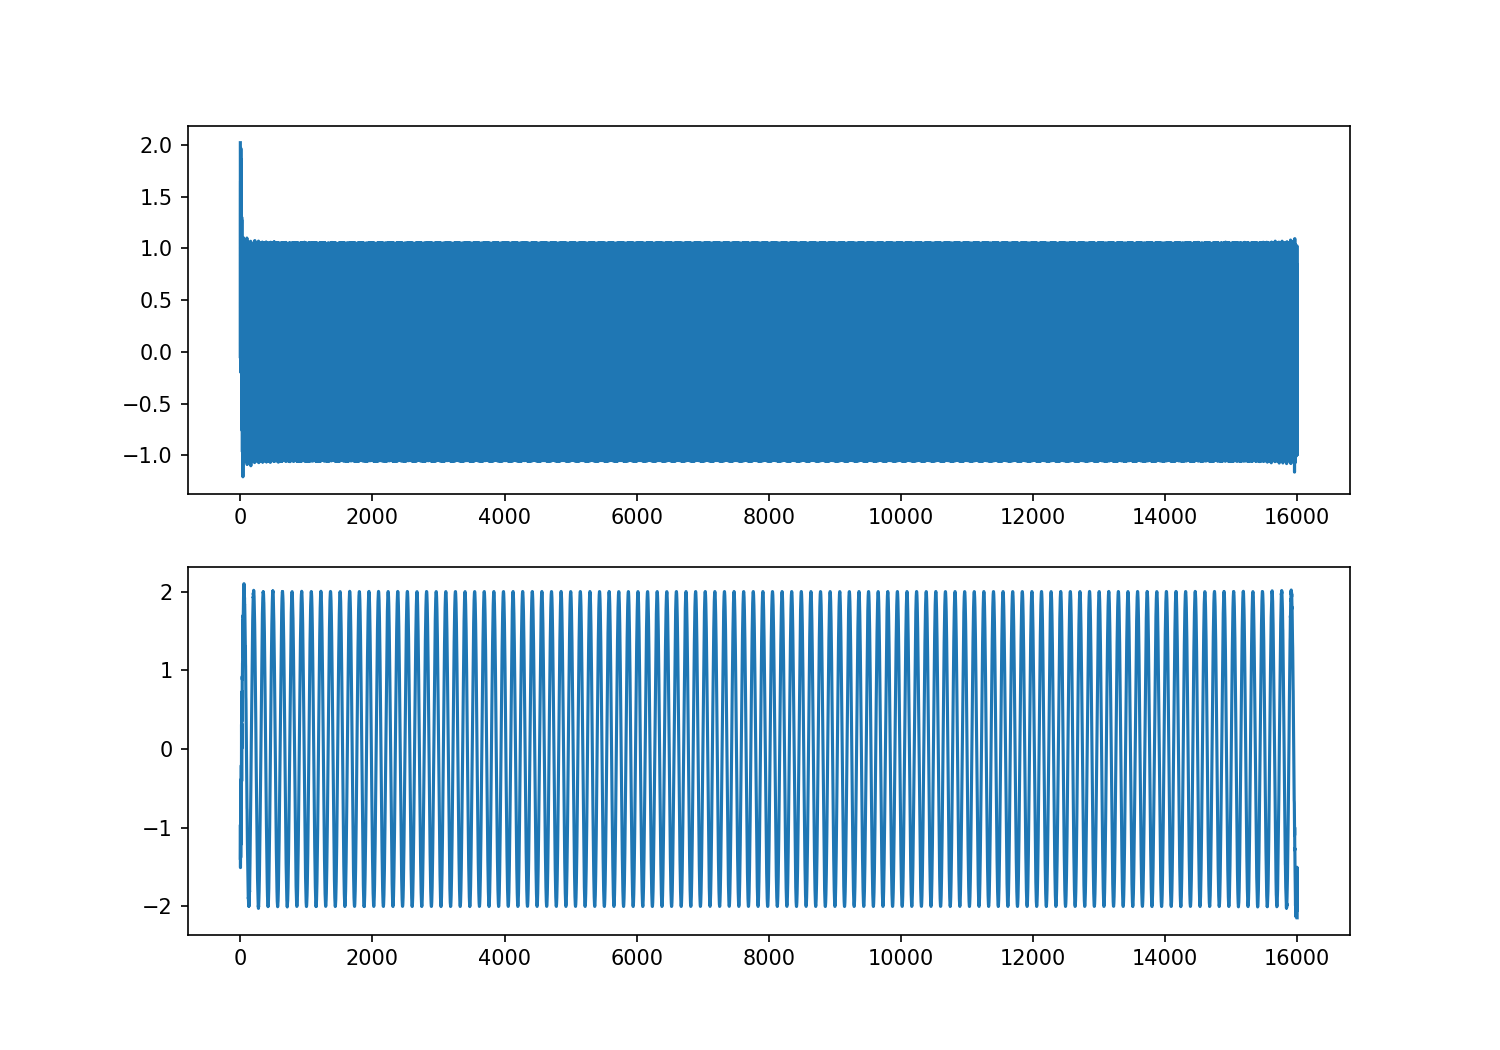

In [8]:
Vm1_f = fft(vn1_f)          
Vm2_f = fft(vn2_f)          

Sm1_f = []                               
Sm2_f = []                      

for x in range(len(Vm1_f)):
    if np.abs(Vm1_f[x]) > np.abs(Vm2_f[x]):
        Sm1_f.insert(x, Vm1_f[x])         
    else:
        Sm1_f.insert(x, 0)  

for x in range(len(Vm2_f)):        
    if np.abs(Vm2_f[x]) > np.abs(Vm1_f[x]):
        Sm2_f.insert(x, Vm2_f[x])
    else:
        Sm2_f.insert(x, 0)
        
sn1_f = np.real(ifft(Sm1_f))           
sn2_f = np.real(ifft(Sm2_f)) 


# Test signal


Vm1f_t = fft(vn1f_t)
Vm2f_t = fft(vn2f_t)

Sm1f_t = []
Sm2f_t = []

for x in range(len(Vm1f_t)):
    if np.abs(Vm1f_t[x]) > np.abs(Vm2f_t[x]):
        Sm1f_t.insert(x, Vm1f_t[x])         
    else:
        Sm1f_t.insert(x, 0)  

for x in range(len(Vm2f_t)):        
    if np.abs(Vm2f_t[x]) > np.abs(Vm1f_t[x]):
        Sm2f_t.insert(x, Vm2f_t[x])
    else:
        Sm2f_t.insert(x, 0)

sn1f_t = np.real(ifft(Sm1f_t))           
sn2f_t = np.real(ifft(Sm2f_t)) 

# Graphs to see what happens with our signal when we use our mask calculator with float delay
plt.close(5), plt.figure(5, figsize=(10,7))
plt.subplot(2,1,1)
plt.plot(np.arange(len(sn1f_t)), sn1f_t)
plt.subplot(2,1,2)
plt.plot(np.arange(len(sn2f_t)), sn2f_t)

In [9]:
# Test: Lisen to filtered adult's voice.
Audio(sn_2, rate=fs)   

### Audio file extraction 

In [10]:
# Convert signal back to int16 datatype and extract it to a new audio file.
data_1 = sn_1*0x8000
data_2 = sn_2*0x8000
data_3 = sn1_f*0x8000
data_4 = sn2_f*0x8000
wavfile.write('baby(sn1).wav', fs, data_1.astype(data.T[0].dtype))      # Baby's audio.
wavfile.write('adult(sn2).wav', fs, data_2.astype(data.T[1].dtype))     # Adult's audio.
wavfile.write('baby(sn1f).wav', fs, data_3.astype(data.T[0].dtype))     # Baby's audio with float delay.
wavfile.write('adult(sn2f).wav', fs, data_4.astype(data.T[1].dtype))    # Adult's audio with float delay.